In [1]:
import os
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
from numpy import pi, e
from numpy.linalg import inv, det
from numpy.linalg import norm as LA_norm
from numpy.random import random
from scipy.stats import norm
from sklearn.datasets import make_spd_matrix
from termcolor import colored
import itertools
from itertools import combinations, product

In [2]:
def create_matrix(m, n):
    return np.round(np.random.rand(m, n), 6)

def initial_inputs(flag):
    if flag == 0:
        # Create initial encoder inputs (B, Sigma_W)
        B = np.round(create_matrix(m, n), 6)
        Sigma_W = np.round(make_spd_matrix(m), 6)
        return np.concatenate(([flag], B.reshape((m*n)), Sigma_W.reshape((m*m))))
    else:
        # Create initial decoder inputs (A, Sigma_Z)
        A = np.round(create_matrix(n, m), 6)
        Sigma_Z = np.round(np.diag(random(n)), 6)
        return np.concatenate(([flag], A.reshape((n*m)), Sigma_Z.reshape((n*n))))

def is_close_to_zero(arr, etol):
    return np.allclose(arr, 0, atol=etol)

def is_singular(matrix):
    is_singular = np.linalg.matrix_rank(matrix) < min(matrix.shape)
    if is_singular:
        print(colored('The matrix is singular.', 'red', attrs=['bold']))
    else:
        print(colored('The matrix is not singular.', 'red', attrs=['bold']))

def is_positive_definite(matrix):
    if np.all(np.linalg.eigvals(matrix) > 0):
        print(colored('The matrix is positive definite.', 'red', attrs=['bold']))
    else:
        print(colored('The matrix is not positive definite.', 'red', attrs=['bold']))

def matrix_B(A, Sigma_Z, beta, lamda):
    inv_Sigma_Z_hat = inv(Sigma_Z) + 2 * lamda * np.identity(n)
    B = np.round(inv(beta * np.identity(m) + A.T @ inv_Sigma_Z_hat @ A) @ A.T @ inv_Sigma_Z_hat, 6)
    return B

def covariance_matrix_W(A, Sigma_Z, beta, lamda):
    inv_Sigma_Z_hat = inv(Sigma_Z) + 2 * lamda * np.identity(n)
    Sigma_W = np.round(beta * inv(beta * np.identity(m) + A.T @ inv_Sigma_Z_hat @ A), 6)
    return Sigma_W

def matrix_A(B, Sigma_W):
    A = np.round(inv(inv(Sigma_Y) + B.T @ inv(Sigma_W) @ B) @ B.T @ inv(Sigma_W), 6)
    return A

def covariance_matrix_Z(B, Sigma_W):
    Sigma_Z = inv(inv(Sigma_Y) + B.T @ inv(Sigma_W) @ B)
    diagonalized_Sigma_Z = np.round(np.diag(Sigma_Z.diagonal()), 6)
    return diagonalized_Sigma_Z

def covariance_matrix_XV(B, Sigma_V):
    cov_XV = np.round(np.block([[np.identity(m), B @ eigenvectors @ Sigma_V],
                                [(B @ eigenvectors @ Sigma_V).T, Sigma_V]]), 6)
    return cov_XV

def encoder_mi(B, Sigma_W):
    return 0.5 * np.log(det(B @ Sigma_Y @ B.T + Sigma_W) / det(Sigma_W))

def decoder_mi(A, Sigma_Z):
    return 0.5 * np.log(det(A @ A.T + Sigma_Z) / det(Sigma_Z))

def mi_VX(B, Sigma_W):
    return 0.5 * np.log(det(B @ Sigma_Y @ B.T + Sigma_W) / det(sigma_squared * B @ B.T + Sigma_W))

def cov_recon_error(recon, orig):
    norm_diff = LA_norm(orig - recon, 2)
    orig_norm = LA_norm(orig, 2)
    recon_err = round(norm_diff / orig_norm, 4)
    return recon_err

def objective_function(A, B, Sigma_Z, Sigma_W, beta, lamda):
    Sigma_X = B @ Sigma_Y @ B.T + Sigma_W
    
    regularizer = 0.5 * (np.trace(Sigma_X) - np.log(det(Sigma_W)) - m)
    reconstruction = -0.5 * (np.trace(A.T @ inv(Sigma_Z) @ Sigma_Y @ B.T) + \
                             np.trace(inv(Sigma_Z) @ A @ B @ Sigma_Y) - \
                             np.trace(inv(Sigma_Z) @ Sigma_Y) - \
                             np.trace((A.T @ inv(Sigma_Z) @ A) @ Sigma_X) - \
                             n * np.log(2 * pi) - np.log(det(Sigma_Z)))
    l2_norm_loss = np.trace((np.identity(n) - A @ B) @ Sigma_Y @ ((np.identity(n) - A @ B).T) + A @ Sigma_W @ A.T)
    
    return reconstruction + beta * regularizer + lamda * l2_norm_loss

In [3]:
def print_comprehensive_results(beta, lamda, flag, m, n, is_arr):
    if flag == 0:
        # Generate random initial encoder inputs (B, Sigma_W)
        B, Sigma_W = initial_inputs(flag)[1:1+m*n].reshape((m, n)), initial_inputs(flag)[1+m*n:1+m*n+m*m].reshape((m, m))
    else:
        # Generate random initial decoder inputs (A, Sigma_Z)
        A, Sigma_Z = initial_inputs(flag)[1:1+n*m].reshape((n, m)), initial_inputs(flag)[1+n*m:1+n*m+n*n].reshape((n, n))

    if flag == 0:
        opt_sol = rate_distortion(initial_inputs(flag), is_arr, beta, lamda)
            
        en_mi = round(opt_sol[2*n*m+n*n+m*m+1:2*n*m+n*n+m*m+2][0], 4)
        de_mi = round(opt_sol[2*n*m+n*n+m*m+2:2*n*m+n*n+m*m+3][0], 4)
        recon_err = round(opt_sol[-1], 4)
            
        return [recon_err, en_mi, de_mi, opt_sol]
    else:
        opt_sol = rate_distortion(initial_inputs(flag), is_arr, beta, lamda)
            
        en_mi = round(opt_sol[2*n*m+n*n+m*m+1:2*n*m+n*n+m*m+2][0], 4)
        de_mi = round(opt_sol[2*n*m+n*n+m*m+2:2*n*m+n*n+m*m+3][0], 4)
        recon_err = round(opt_sol[-1], 4)
            
        return [recon_err, en_mi, de_mi, opt_sol]

In [4]:
"""

*****************************************************************
**                          ALGORITHM                          **
*****************************************************************
   
Inputs:
- MAX_ITERS: Maximum number of iterations
- n, m: Dimensions of the matrix
- TOL_ERR: Tolerable error
- Sigma_Y: A random nxn positive definite matrix

Algorithm:
1. Initialize flag
    a. If we start with the encoder, set flag = 0.
    b. Otherwise, set flag = 1.
    
2. Generate initial inputs for the iteration step
    a. If flag = 0, then do:
        i. create random initial encoder inputs, including 
            - a random mxn matrix B
            - a random mxm positive definite covariance matrix Sigma_W
        ii. set flag = 1.
    b. If flag = 1, then do:
        i. create random initial decoder inputs, including 
            - a random nxm matrix A
            - a random nxn positive definite covariance matrix Sigma_Z
        ii. set flag = 0.
        
3. Set iteration counter i = 0. 

4. Iterative step
    a. If flag = 0, given the decoder inputs (A, Sigma_Z) at iteration i,
        i. compute the corresponding encoder inputs at iteration i+1:
            B = matrix_B(A, Sigma_Z)
            Sigma_W = covariance_matrix_W(A, Sigma_Z)
        ii. set flag = 1.
        iii. compute the resulting beta-VAE cost function and mutual information of the encoder.
        iv. check if the cost function is NaN:
            - if it is, conclude that the algorithm fails to converge and skip to step 7.
        v. check for convergence after the second iteration:
            - if converges, conclude that the algorithm converges and skip to step 7.
            - unless, check if the maximum number of iterations has been reached:
                - if it is, conclude that the algorithm failed to converge and skip to step 7.
                - otherwise, move to step 5.
    b. If flag = 1, given the encoder inputs (B, Sigma_W) at iteration i,
        i. compute the corresponding decoder inputs at iteration i:
            A = matrix_A(B, Sigma_W)
            Sigma_Z = covariance_matrix_Z(B, Sigma_W, is_diagonal)
        ii. set flag = 0.
        iii. compute the resulting beta-VAE cost function, mutual information of the decoder, and reconstruction error.
        iv. check if the cost function is NaN:
            - if it is, conclude that the algorithm fails to converge and skip to step 7.
        v. check for convergence after the second iteration:
            - if converges, conclude that the algorithm converges and skip to step 7.
            - unless, check if the maximum number of iterations has been reached:
                - if it is, conclude that the algorithm failed to converge and skip to step 7.
                - otherwise, move to step 5.
            
5. Increment iteration counter i <- i + 1.

6. If the iteration counter i < MAX_ITERS, then move back to step 4.
    Otherwise, move to step 7.
    
7. Compute the values of Sigma_X and Sigma_Y_hat.
        
8. Display results
    
9. Stop.

"""

def rate_distortion(inputs, is_arr, beta, lamda):
    flag = inputs[0]
    if flag == 0:
        B = inputs[1:1+m*n].reshape((m, n))
        Sigma_W = inputs[1+m*n:1+m*n+m*m].reshape((m, m))
        flag = 1
        # Array of current encoder inputs (B_t, Sigma_W_t)
        current_encoder_inputs = np.concatenate((B.reshape((m*n)), Sigma_W.reshape((m*m))))
    else:
        A = inputs[1:1+n*m].reshape((n, m))
        Sigma_Z = inputs[1+n*m:1+n*m+n*n].reshape((n, n))
        flag = 0
        # Array of current decoder inputs (A_t, Sigma_Z_t)
        current_decoder_inputs = np.concatenate((A.reshape((n*m)), Sigma_Z.reshape((n*n))))
    
    # Cost function and mutual information arrays
    cf_arr = []
    en_mi_arr = []
    de_mi_arr = [] 

    # Iteration step
    try:
        for i in range(0, MAX_ITERS):
            if  flag == 0:
                B = np.round(matrix_B(A, Sigma_Z, beta, lamda), 6)
                Sigma_W = np.round(covariance_matrix_W(A, Sigma_Z, beta, lamda), 6)
                flag = 1
                
                # Check if the value of the cost function is not a number
                current_obj = round(objective_function(A, B, Sigma_Z, Sigma_W, beta, lamda), 6)
                if np.isnan(current_obj):
                    if is_arr == 0:
                        print(colored('\nThe algorithm fails to converge after {} iterations due to NaN values.\n'.format(i+1), 'red', attrs=['bold']))
                    break
                    
                cf_arr = np.concatenate((cf_arr, [current_obj]))
                current_en_mi = encoder_mi(B, Sigma_W)
                en_mi_arr = np.concatenate((en_mi_arr, [current_en_mi]))
                
                # For the first iteration, update the current encoder inputs and value of the cost function
                if i == 0:
                    current_encoder_inputs = np.concatenate((B.reshape((m*n)), Sigma_W.reshape((m*m))))
                    previous_obj = current_obj
                # From the second iteration,
                # 1. Compute the Frobenius norm of the difference between
                #    i. B and itself in the previous iteration
                #    ii. Sigma_W and itself in the previous iteration
                # 2. Compute the difference between the cost function and itself in the previous iteration
                # 3. Update the current encoder inputs and value of the cost function
                else:
                    B_diff = B - current_encoder_inputs[:m*n].reshape((m, n))
                    B_norm_diff = LA_norm(B_diff, 'fro')
                    Sigma_W_diff = Sigma_W - current_encoder_inputs[m*n:m*n+m*m].reshape((m, m))
                    Sigma_W_norm_diff = LA_norm(Sigma_W_diff, 'fro')
                    obj_diff = previous_obj - current_obj
                    previous_obj = current_obj
                    current_encoder_inputs = np.concatenate((B.reshape((m*n)), Sigma_W.reshape((m*m))))
                    # Check for convergence
                    if B_norm_diff <= TOL_ERR and Sigma_W_norm_diff <= TOL_ERR:
                        if is_arr == 0:
                            print(colored('\nThe algorithm converges after {} iterations.\n'.format(i+1), 'blue', attrs=['bold']))
                        break
            else:
                A = np.round(matrix_A(B, Sigma_W), 6)
                Sigma_Z = np.round(covariance_matrix_Z(B, Sigma_W), 6)
                flag = 0
                
                current_obj = round(objective_function(A, B, Sigma_Z, Sigma_W, beta, lamda), 6)
                if np.isnan(current_obj):
                    if is_arr == 0:
                        print(colored('\nThe algorithm fails to converge after {} iterations due to NaN values.\n'.format(i+1), 'red', attrs=['bold']))
                    break
                    
                cf_arr = np.concatenate((cf_arr, [current_obj]))
                current_de_mi = decoder_mi(A, Sigma_Z)
                de_mi_arr = np.concatenate((de_mi_arr, [current_de_mi]))
                
                Sigma_Y_hat = A @ A.T + Sigma_Z
                recon_err = cov_recon_error(Sigma_Y_hat, Sigma_Y)
                
                # For the first iteration, update the current decoder inputs and value of the cost function
                if i == 0:
                    current_decoder_inputs = np.concatenate((A.reshape((n*m)), Sigma_Z.reshape((n*n))))
                    previous_obj = current_obj
                # From the second iteration,
                # 1. Compute the Frobenius norm of the difference between
                #    i. A and itself in the previous iteration
                #    ii. Sigma_Z and itself in the previous iteration
                # 2. Compute the difference between the cost function and itself in the previous iteration
                # 3. Update the current dencoder inputs and value of the cost function                
                else:
                    A_diff = A - current_decoder_inputs[:n*m].reshape((n, m))
                    A_norm_diff = LA_norm(A_diff, 'fro')
                    Sigma_Z_diff = Sigma_Z - current_decoder_inputs[n*m:n*m+n*n].reshape((n, n))
                    Sigma_Z_norm_diff = LA_norm(Sigma_Z_diff, 'fro')
                    obj_diff = previous_obj - current_obj
                    previous_obj = current_obj
                    current_decoder_inputs = np.concatenate((A.reshape((n*m)), Sigma_Z.reshape((n*n))))
                    # Check for convergence
                    if A_norm_diff <= TOL_ERR and Sigma_Z_norm_diff <= TOL_ERR:
                        if is_arr == 0:
                            print(colored('\nThe algorithm converges after {} iterations.\n'.format(i+1), 'blue', attrs=['bold']))
                        break                       

        # Compute Sigma_X and Sigma_Y_hat  
        Sigma_X = B @ Sigma_Y @ B.T + Sigma_W
        Sigma_Y_hat = A @ A.T + Sigma_Z
        
        sol = np.concatenate((A.reshape((n*m)), B.reshape((m*n)),
                              Sigma_Z.reshape((n*n)), Sigma_W.reshape((m*m)),
                              [current_obj], [current_en_mi], [current_de_mi],
                              [len(cf_arr)], [len(en_mi_arr)], [len(de_mi_arr)],
                              Sigma_X.reshape((m*m)), Sigma_Y_hat.reshape((n*n)),
                              cf_arr, en_mi_arr, de_mi_arr, [recon_err]))
        return sol
    
    except Exception as e:
         
        Sigma_X = B @ Sigma_Y @ B.T + Sigma_W
        Sigma_Y_hat = A @ A.T + Sigma_Z
        
        sol = np.concatenate((A.reshape((n*m)), B.reshape((m*n)),
                              Sigma_Z.reshape((n*n)), Sigma_W.reshape((m*m)),
                              [current_obj], [current_en_mi], [current_de_mi], 
                              [len(cf_arr)], [len(en_mi_arr)], [len(de_mi_arr)],
                              Sigma_X.reshape((m*m)), Sigma_Y_hat.reshape((n*n)),
                              cf_arr, en_mi_arr, de_mi_arr, [recon_err]))
        return sol

In [5]:
def generate_Sigma_V(case):
    for case_idx in range(num_cases):
        if case_idx == 0:
            # Case 1: Independent of generative parameters
            std_devs = [std_dev_v1, std_dev_v2, std_dev_v3]
            V_1 = [np.random.normal(mean, std_dev, size=num_samples) for std_dev in std_devs]

            # Compute covariance matrix of V 
            Sigma_V_1 = np.round(np.cov(V_1), 4)
        
        elif case_idx == 1:
            # Case 2: Linear dependence of v_1 and v_2, with independence of v_3
            v_1 = np.random.normal(mean, std_dev_v1, size=num_samples)
            v_3 = np.random.normal(mean, std_dev_v3, size=num_samples)
            
            # Calculate v_2 using scaling factor alpha and random noise
            random_noise_z2 = np.random.normal(mean, std_dev_z2, num_samples)
            v_2 = alpha * v_1 + random_noise_z2
            
            # Create generative variable V
            V_2 = np.array([v_1, v_2, v_3])

            # Compute covariance matrix of V 
            Sigma_V_2 = np.round(np.cov(V_2), 4)  
        
        else:
            # Case 3: Linear dependence of v_2 and v_3, with v_1
            v_1 = np.random.normal(mean, std_dev_v1, size=num_samples)
            
            # Calculate additional generative parameters using scaling factors
            random_noise_z2 = np.random.normal(mean, std_dev_z2, num_samples)
            random_noise_z3 = np.random.normal(mean, std_dev_z3, num_samples)
            v_2 = alpha * v_1 + random_noise_z2
            v_3 = beta_reg * v_1 + random_noise_z3

            # Create generative variable V
            V_3 = np.array([v_1, v_2, v_3])

            # Compute covariance matrix of V 
            Sigma_V_3 = np.round(np.cov(V_3), 4)
    
    if case == 0:
        print(colored('Scenario 1:', attrs=['bold','underline']))
        print(f'Given (sigma_v1, sigma_v2, sigma_v3) = {std_dev_v1, std_dev_v2, std_dev_v3}:')
        print(colored('\nCovariance matrix of generative variable V:', attrs=['bold']))
        print(Sigma_V_1)
        is_singular(Sigma_V_1)
        return Sigma_V_1
    
    elif case == 1:
        print(colored('\nScenario 2:', attrs=['bold','underline']))
        print(f'Given (sigma_v1, sigma_v3) = {std_dev_v1, std_dev_v3}, alpha = {alpha}, and sigma_z2 = {std_dev_z2}:')
        print(colored('\nCovariance matrix of generative variable V:', attrs=['bold']))
        print(Sigma_V_2)
        is_singular(Sigma_V_2) 
        return Sigma_V_2
    
    else:
        print(colored('\nScenario 3:', attrs=['bold','underline']))
        print(f'Given sigma_v1 = {std_dev_v1}, (alpha, beta) = {alpha, beta_reg}, and (sigma_z2, sigma_z3) = {std_dev_z2, std_dev_z3}:')
        print(colored('\nCovariance matrix of generative variable V:', attrs=['bold']))
        print(Sigma_V_3)
        is_singular(Sigma_V_3)  
        return Sigma_V_3

## I. Inputs

In [6]:
# Constants
MAX_ITERS = 10000
s, n, m = 3, 4, 3
TOL_ERR = 1e-4
MAX_RECON_ERR = 0.05

num_cases = 3
num_samples = int(1e7)
alpha = 2
beta_reg = 3
mean = 0
std_dev_v1 = 0.05
std_dev_v2 = 0.06
std_dev_v3 = 0.07
std_dev_z2 = 0.02
std_dev_z3 = 0.03

# Arrays of beta and lambda
beta_arr = np.array([0.7, 0.75, 0.8, 0.85, 0.9, 0.95, 1, 1.05, 1.1, 1.15, 1.2])
print(colored('An array of beta:', 'blue', attrs=['bold']))
print('{}'.format(beta_arr))

lambda_arr = np.array([0, 0.1, 0.2])
print(colored('\nAn array of lambda:', 'blue', attrs=['bold']))
print('{}'.format(lambda_arr))

# Independent eigenvectors
eigenvectors = np.array([[1, 0, 0],
                         [0, 1, 0],
                         [0, 0, 1],
                         [0, 0, 0]])
print(colored('\nIndependent eigenvectors:', 'blue', attrs=['bold']))
print(eigenvectors)

# Covariance of noise Z_tilde
sigma_squared = 0.04**2
Sigma_Z_tilde = sigma_squared * np.identity(n)
print(colored('\nCovariance of noise Z_tilde:', 'blue', attrs=['bold']))
print(np.round(Sigma_Z_tilde, 4))

An array of beta:
[0.7  0.75 0.8  0.85 0.9  0.95 1.   1.05 1.1  1.15 1.2 ]

An array of lambda:
[0.  0.1 0.2]

Independent eigenvectors:
[[1 0 0]
 [0 1 0]
 [0 0 1]
 [0 0 0]]

Covariance of noise Z_tilde:
[[0.0016 0.     0.     0.    ]
 [0.     0.0016 0.     0.    ]
 [0.     0.     0.0016 0.    ]
 [0.     0.     0.     0.0016]]


## II. Partitioning

In [7]:
print(colored('All ways to divide the indices of the generative parameters into three distinct groups:\n', attrs=['bold']))

V_indices = np.arange(m+1, m+s+1)

group_1_list_V = []
group_2_list_V = []
group_3_list_V = []
group_1_list_XV = []
group_2_list_XV = []
group_3_list_XV = []

# Initialize an empty list to store valid partitions
valid_partitions = []

# Generate all possible ways to divide the indices of parameters into 3 groups (may be empty)
V_indices = np.arange(m+1, m+s+1)

for i in range(len(V_indices) + 1):
    for j in range(len(V_indices) + 1):
        if i + j <= len(V_indices):
            group_1_combinations = combinations(V_indices, i)
            for group_1 in group_1_combinations:
                remaining_indices_1 = set(V_indices) - set(group_1)
                group_2_combinations = combinations(remaining_indices_1, j)
                for group_2 in group_2_combinations:
                    group_3 = tuple(index for index in V_indices if index not in group_1 and index not in group_2)
                    valid_partitions.append((set(group_1), set(group_2), set(group_3)))

for idx, partition in enumerate(valid_partitions, start=1):
    group_1, group_2, group_3 = partition
    print(f'Partition {idx}: Group 1: {group_1}, Group 2: {group_2}, Group 3: {group_3}')

    # Add group information to respective lists
    group_1_list_V.append(list(group_1))
    group_2_list_V.append(list(group_2))
    group_3_list_V.append(list(group_3))
    
    group_1_list_XV.append([1] + list(group_1))   
    group_2_list_XV.append([2] + list(group_2))
    group_3_list_XV.append([3] + list(group_3))

All ways to divide the indices of the generative parameters into three distinct groups:

Partition 1: Group 1: set(), Group 2: set(), Group 3: {4, 5, 6}
Partition 2: Group 1: set(), Group 2: {4}, Group 3: {5, 6}
Partition 3: Group 1: set(), Group 2: {5}, Group 3: {4, 6}
Partition 4: Group 1: set(), Group 2: {6}, Group 3: {4, 5}
Partition 5: Group 1: set(), Group 2: {4, 5}, Group 3: {6}
Partition 6: Group 1: set(), Group 2: {4, 6}, Group 3: {5}
Partition 7: Group 1: set(), Group 2: {5, 6}, Group 3: {4}
Partition 8: Group 1: set(), Group 2: {4, 5, 6}, Group 3: set()
Partition 9: Group 1: {4}, Group 2: set(), Group 3: {5, 6}
Partition 10: Group 1: {5}, Group 2: set(), Group 3: {4, 6}
Partition 11: Group 1: {6}, Group 2: set(), Group 3: {4, 5}
Partition 12: Group 1: {4}, Group 2: {5}, Group 3: {6}
Partition 13: Group 1: {4}, Group 2: {6}, Group 3: {5}
Partition 14: Group 1: {5}, Group 2: {4}, Group 3: {6}
Partition 15: Group 1: {5}, Group 2: {6}, Group 3: {4}
Partition 16: Group 1: {6}, Gr

In [8]:
# Initialize the result arrays with empty lists
group_list_v1v2 = [[] for _ in range(len(group_1_list_V))]
group_list_v1v3 = [[] for _ in range(len(group_1_list_V))]
group_list_v2v3 = [[] for _ in range(len(group_1_list_V))]

# Function to combine arrays
def combine_arrays(result, arr):
    for i in range(len(arr)):
        if arr[i]:
            result[i].extend(arr[i])

# Combine group_1_list_V and group_2_list_V
combine_arrays(group_list_v1v2, group_1_list_V)
combine_arrays(group_list_v1v2, group_2_list_V)

# Combine group_1_list_V and group_3_list_V
combine_arrays(group_list_v1v3, group_1_list_V)
combine_arrays(group_list_v1v3, group_3_list_V)

# Combine group_2_list_V and group_3_list_V
combine_arrays(group_list_v2v3, group_2_list_V)
combine_arrays(group_list_v2v3, group_3_list_V)

## III. Numerical results

In [9]:
def compute_I3(det_v1, det_v2, det_v3, det_x1v1, det_x2v2, det_x3v3, 
               det_v1v2, det_v1v3, det_v2v3, len_group_1, len_group_2, len_group_3):
    
    # 2 groups are empty
    if len_group_1 == 0 and len_group_2 == 0:
        I_3 = round(0.5 * np.log(det_v3/det_x3v3), 4)
    elif len_group_1 == 0 and len_group_3 == 0:
        I_3 = round(0.5 * np.log(det_v2/det_x2v2), 4)
    elif len_group_2 == 0 and len_group_3 == 0:
        I_3 = round(0.5 * np.log(det_v1/det_x1v1), 4)
    
    # 1 group is empty
    elif len_group_1 == 0:
        I_3 = round(0.5 * (np.log(det_v2/det_x2v2) + \
                           np.log(det_v3/det_x3v3) - \
                           np.log(det_v2*det_v3/det_v2v3)), 4)
    elif len_group_2 == 0:
        I_3 = round(0.5 * (np.log(det_v1/det_x1v1) + \
                           np.log(det_v3/det_x3v3) - \
                           np.log(det_v1*det_v3/det_v1v3)), 4)
    elif len_group_3 == 0:
        I_3 = round(0.5 * (np.log(det_v1/det_x1v1) + \
                           np.log(det_v2/det_x2v2) - \
                           np.log(det_v1*det_v2/det_v1v2)), 4)
        
    # None of the groups are empty
    else:
        I_3 = round(0.5 * (np.log(det_v1/det_x1v1) + \
                           np.log(det_v2/det_x2v2) + \
                           np.log(det_v3/det_x3v3) - \
                           np.log(det_v1*det_v2/det_v1v2) - \
                           np.log(det_v1*det_v3/det_v1v3) - \
                           np.log(det_v2*det_v3/det_v2v3)), 4)
    return I_3

In [10]:
def find_two_largest_values(a, b, c):
    values = {"1": a, "2": b, "3": c}
    sorted_values = sorted(values.items(), key=lambda x: x[1], reverse=True)
    (name1, value1), (name2, value2) = sorted_values[:2]
    return (name1, value1), (name2, value2)

def compute_SAP(Cov_x1v1, Cov_x2v1, Cov_x3v1,
                Cov_x1v2, Cov_x2v2, Cov_x3v2,
                Cov_x1v3, Cov_x2v3, Cov_x3v3, SAP_flag):   

    S_11 = (Cov_x1v1/std_dev_v1) ** 2 
    S_21 = (Cov_x2v1/std_dev_v1) ** 2 
    S_31 = (Cov_x3v1/std_dev_v1) ** 2 
    
    S_12 = (Cov_x1v2/std_dev_v2) ** 2 
    S_22 = (Cov_x2v2/std_dev_v2) ** 2 
    S_32 = (Cov_x3v2/std_dev_v2) ** 2 
    
    S_13 = (Cov_x1v3/std_dev_v3) ** 2 
    S_23 = (Cov_x2v3/std_dev_v3) ** 2 
    S_33 = (Cov_x3v3/std_dev_v3) ** 2
    
    result1_v1, result2_v1 = find_two_largest_values(S_11, S_21, S_31)
    result1_v2, result2_v2 = find_two_largest_values(S_12, S_22, S_32)
    result1_v3, result2_v3 = find_two_largest_values(S_13, S_23, S_33)
          
    diff_1 = result1_v1[1] - result2_v1[1]
    diff_2 = result1_v2[1] - result2_v2[1]
    diff_3 = result1_v3[1] - result2_v3[1]
    
    SAP = round(1/s * (diff_1 + diff_2 + diff_3), 4)
    print(colored(f'\nSAP = {SAP}', 'green', attrs=['bold']))
    
    return SAP

In [11]:
def max_I3(cov_XV, I3_flag):
    max_MI = -1000
    max_idx = 0
    
    det_x1v1_arr = []
    det_x2v2_arr = []
    det_x3v3_arr = []

    # Generate an array of indices
    for i, (group_1_idx_V, group_2_idx_V, group_3_idx_V,
            group_1_idx_XV, group_2_idx_XV, group_3_idx_XV,
            group_idx_v1v2, group_idx_v1v3, group_idx_v2v3) in enumerate(zip(group_1_list_V, group_2_list_V, group_3_list_V,
                                                                             group_1_list_XV, group_2_list_XV, group_3_list_XV,
                                                                             group_list_v1v2, group_list_v1v3, group_list_v2v3)):
        
        # Generate two-digit numbers with repetition from the array and in increasing order
        group_1_two_digit_numbers_V = [int(str(a) + str(b)) for a, b in product(group_1_idx_V, repeat=2)]
        group_2_two_digit_numbers_V = [int(str(a) + str(b)) for a, b in product(group_2_idx_V, repeat=2)]
        group_3_two_digit_numbers_V = [int(str(a) + str(b)) for a, b in product(group_3_idx_V, repeat=2)]
        
        group_1_two_digit_numbers_XV = [int(str(a) + str(b)) for a, b in product(group_1_idx_XV, repeat=2)]
        group_2_two_digit_numbers_XV = [int(str(a) + str(b)) for a, b in product(group_2_idx_XV, repeat=2)]
        group_3_two_digit_numbers_XV = [int(str(a) + str(b)) for a, b in product(group_3_idx_XV, repeat=2)]
        
        group_two_digit_numbers_v1v2 = [int(str(a) + str(b)) for a, b in product(group_idx_v1v2, repeat=2)]
        group_two_digit_numbers_v1v3 = [int(str(a) + str(b)) for a, b in product(group_idx_v1v3, repeat=2)]
        group_two_digit_numbers_v2v3 = [int(str(a) + str(b)) for a, b in product(group_idx_v2v3, repeat=2)]
    
        # Specify the positions to extract
        tuple_list_1_V = [(number // 10 - 1, number % 10 - 1) for number in group_1_two_digit_numbers_V]
        tuple_list_2_V = [(number // 10 - 1, number % 10 - 1) for number in group_2_two_digit_numbers_V]
        tuple_list_3_V = [(number // 10 - 1, number % 10 - 1) for number in group_3_two_digit_numbers_V]
        
        tuple_list_1_XV = [(number // 10 - 1, number % 10 - 1) for number in group_1_two_digit_numbers_XV]
        tuple_list_2_XV = [(number // 10 - 1, number % 10 - 1) for number in group_2_two_digit_numbers_XV]
        tuple_list_3_XV = [(number // 10 - 1, number % 10 - 1) for number in group_3_two_digit_numbers_XV]
        
        tuple_list_v1v2 = [(number // 10 - 1, number % 10 - 1) for number in group_two_digit_numbers_v1v2]
        tuple_list_v1v3 = [(number // 10 - 1, number % 10 - 1) for number in group_two_digit_numbers_v1v3]
        tuple_list_v2v3 = [(number // 10 - 1, number % 10 - 1) for number in group_two_digit_numbers_v2v3]
    
        # Get the new matrix from specified positions
        dim_v1 = len(group_1_idx_V)
        dim_v2 = len(group_2_idx_V)
        dim_v3 = len(group_3_idx_V)
        
        dim_x1v1 = len(group_1_idx_XV)
        dim_x2v2 = len(group_2_idx_XV)
        dim_x3v3 = len(group_3_idx_XV)
        
        dim_v1v2 = len(group_idx_v1v2)
        dim_v1v3 = len(group_idx_v1v3)
        dim_v2v3 = len(group_idx_v2v3)
    
        cov_v1 = np.array([cov_XV[i, j] for i, j in tuple_list_1_V]).reshape(dim_v1, dim_v1)
        if len(cov_v1) == 1:
            cov_v1 = cov_v1[0]
        cov_v2 = np.array([cov_XV[i, j] for i, j in tuple_list_2_V]).reshape(dim_v2, dim_v2)
        if len(cov_v2) == 1:
            cov_v2 = cov_v2[0]
        cov_v3 = np.array([cov_XV[i, j] for i, j in tuple_list_3_V]).reshape(dim_v3, dim_v3)
        if len(cov_v3) == 1:
            cov_v3 = cov_v3[0]
    
        cov_x1v1 = np.array([cov_XV[i, j] for i, j in tuple_list_1_XV]).reshape(dim_x1v1, dim_x1v1)
        cov_x2v2 = np.array([cov_XV[i, j] for i, j in tuple_list_2_XV]).reshape(dim_x2v2, dim_x2v2)
        cov_x3v3 = np.array([cov_XV[i, j] for i, j in tuple_list_3_XV]).reshape(dim_x3v3, dim_x3v3)
        
        cov_v1v2 = np.array([cov_XV[i, j] for i, j in tuple_list_v1v2]).reshape(dim_v1v2, dim_v1v2)
        cov_v1v3 = np.array([cov_XV[i, j] for i, j in tuple_list_v1v3]).reshape(dim_v1v3, dim_v1v3)
        cov_v2v3 = np.array([cov_XV[i, j] for i, j in tuple_list_v2v3]).reshape(dim_v2v3, dim_v2v3)
    
        # Compute the determinant of each covariance matrix
        det_x1v1 = det(cov_x1v1)
        det_x2v2 = det(cov_x2v2)
        det_x3v3 = det(cov_x3v3)
        
        det_v1v2 = det(cov_v1v2)
        det_v1v3 = det(cov_v1v3)
        det_v2v3 = det(cov_v2v3)
        
        if len(cov_v1) == 1:
            det_v1 = cov_v1[0]
            det_x1v1_arr.append(det_x1v1) 
        else:    
            det_v1 = det(cov_v1)
            
        if len(cov_v2) == 1:
            det_v2 = cov_v2[0]
            det_x2v2_arr.append(det_x2v2) 
        else:    
            det_v2 = det(cov_v2)
            
        if len(cov_v3) == 1:
            det_v3 = cov_v3[0]
            det_x3v3_arr.append(det_x3v3) 
        else:    
            det_v3 = det(cov_v3)
        
        # Compute I_3
        I_3 = compute_I3(det_v1, det_v2, det_v3, 
                         det_x1v1, det_x2v2, det_x3v3, 
                         det_v1v2, det_v1v3, det_v2v3,
                         len(group_1_idx_V), len(group_2_idx_V), len(group_3_idx_V))
    
        if I_3 > max_MI:
            max_MI = I_3
            max_idx = i+1
        
    print(colored(f'\nThe maximum value of I_3 is {round(max_MI, 4)} at Partition {max_idx}.', 'blue', attrs=['bold']))
    
    partition = max_idx
    
    if 12 <= partition <= 17:
        print('Each factor can be captured by a single latent variable.') 
    elif partition in [1, 8, 27]:
        print('(v1, v2, v3) can be captured by a single latent variable.')
    elif partition in [4, 5, 11, 20, 21, 24]:
        print('(v1, v2) are captured by one latent variable and v3 by a second latent variable.')
    elif partition in [3, 6, 10, 19, 22, 25]:
        print('(v1, v3) are captured by one latent variable and v2 by a second latent variable.')
    else:
        print('(v2, v3) are captured by one latent variable and v1 by a second latent variable.')
    
    count = 0
    
    if I3_flag == 0 and 12 <= partition <= 17:
        count = 1
        
    if I3_flag == 1 and partition in [4, 5, 11, 20, 21, 24]:
        count = 1
        
    if I3_flag == 2 and partition in [1, 8, 27]:
        count = 1
    
    return max_MI, count

In [12]:
all_I3_score_arr = []
all_SAP_score_arr = []
I3_count_arr = []
min_recon_err_arr = []
min_en_mi_arr = []
min_de_mi_arr = []

for case in range(num_cases):
    # Compute Sigma_Y given Sigma_V
    Sigma_V = generate_Sigma_V(case)
    Sigma_Y = eigenvectors @ Sigma_V @ eigenvectors.T + Sigma_Z_tilde
    
    print(colored('\nCovariance matrix of input data Y:', attrs=['bold']))
    print(np.round(Sigma_Y, 4))
    is_positive_definite(Sigma_Y)
    
    # Compute the determiant of each generative variable
    diagonal_elements = [Sigma_V[i, i] for i in range(s)]
    det_v_1, det_v_2, det_v_3 = diagonal_elements[0], diagonal_elements[1], diagonal_elements[2]
    
    # Constants
    MAX_SOLS = 200
    is_array = 1
    flag = 0
    case_num = 1
    
    # Iteration step
    for i in range(0, len(beta_arr)):
        beta = beta_arr[i]
        for j in range(0, len(lambda_arr)):
            lamda = lambda_arr[j]
            print(colored('\nGiven (beta, lambda) = ({}, {}):'.format(beta, lamda), 'yellow', attrs=['bold', 'underline']))

            for iter in range (0, MAX_SOLS):
                print(colored('\nSolution {}:'.format(iter+1), attrs=['bold']))
                min_recon_err, min_en_mi, min_de_mi, min_opt_sol = print_comprehensive_results(beta, lamda, flag, m, n, is_array)

                # Compute I_3
                B_opt = np.round(min_opt_sol[n*m:2*n*m].reshape((m, n)), 6)
                Sigma_W_opt = np.round(min_opt_sol[2*n*m+n*n:2*n*m+n*n+m*m].reshape((m, m)), 6)
                
                cov_XV = covariance_matrix_XV(B_opt, Sigma_V)
            
                I3_flag = case
                I3_max, I3_count = max_I3(cov_XV, I3_flag)
                    
                # Extract elements from covariance matrix (X,V)
                Cov_x1v1 = cov_XV[0, 3]
                Cov_x2v1 = cov_XV[1, 3]
                Cov_x3v1 = cov_XV[2, 3]

                Cov_x1v2 = cov_XV[0, 4]
                Cov_x2v2 = cov_XV[1, 4]
                Cov_x3v2 = cov_XV[2, 4]

                Cov_x1v3 = cov_XV[0, 5]
                Cov_x2v3 = cov_XV[1, 5]
                Cov_x3v3 = cov_XV[2, 5]
            
                # Compute SAP
                SAP_flag = case
                SAP_score = compute_SAP(Cov_x1v1, Cov_x2v1, Cov_x3v1,
                                        Cov_x1v2, Cov_x2v2, Cov_x3v2,
                                        Cov_x1v3, Cov_x2v3, Cov_x3v3, SAP_flag)

                all_I3_score_arr.append(I3_max)
                I3_count_arr.append(I3_count)
                all_SAP_score_arr.append(SAP_score)
                min_recon_err_arr.append(min_recon_err)
                min_en_mi_arr.append(min_en_mi)
                min_de_mi_arr.append(min_de_mi)

Scenario 1:
Given (sigma_v1, sigma_v2, sigma_v3) = (0.05, 0.06, 0.07):

Covariance matrix of generative variable V:
[[ 0.0025  0.     -0.    ]
 [ 0.      0.0036  0.    ]
 [-0.      0.      0.0049]]
The matrix is not singular.

Covariance matrix of input data Y:
[[0.0041 0.     0.     0.    ]
 [0.     0.0052 0.     0.    ]
 [0.     0.     0.0065 0.    ]
 [0.     0.     0.     0.0016]]
The matrix is positive definite.

Given (beta, lambda) = (0.7, 0.0):

Solution 1:

The maximum value of I_3 is 1.0958 at Partition 3.
(v1, v3) are captured by one latent variable and v2 by a second latent variable.

SAP = 0.1439

Solution 2:

The maximum value of I_3 is 0.8477 at Partition 22.
(v1, v3) are captured by one latent variable and v2 by a second latent variable.

SAP = 0.1522

Solution 3:

The maximum value of I_3 is 1.8321 at Partition 15.
Each factor can be captured by a single latent variable.

SAP = 0.6292

Solution 4:

The maximum value of I_3 is 0.9884 at Partition 12.
Each factor can be c

/tmp/ipykernel_2480063/3264598766.py:18: RuntimeWarning: invalid value encountered in log
  I_3 = round(0.5 * (np.log(det_v1/det_x1v1) + \
/tmp/ipykernel_2480063/3264598766.py:22: RuntimeWarning: invalid value encountered in log
  I_3 = round(0.5 * (np.log(det_v1/det_x1v1) + \
/tmp/ipykernel_2480063/3264598766.py:10: RuntimeWarning: invalid value encountered in log
  I_3 = round(0.5 * np.log(det_v1/det_x1v1), 4)
/tmp/ipykernel_2480063/3264598766.py:28: RuntimeWarning: invalid value encountered in log
  I_3 = round(0.5 * (np.log(det_v1/det_x1v1) + \



The maximum value of I_3 is 0.952 at Partition 1.
(v1, v2, v3) can be captured by a single latent variable.

SAP = 1.3056

Solution 12:

The maximum value of I_3 is 0.0903 at Partition 8.
(v1, v2, v3) can be captured by a single latent variable.

SAP = 2.3827

Solution 13:

The maximum value of I_3 is 0.6494 at Partition 1.
(v1, v2, v3) can be captured by a single latent variable.

SAP = 1.6381

Solution 14:

The maximum value of I_3 is 0.5292 at Partition 1.
(v1, v2, v3) can be captured by a single latent variable.

SAP = 1.1319

Solution 15:

The maximum value of I_3 is 0.6729 at Partition 27.
(v1, v2, v3) can be captured by a single latent variable.

SAP = 0.9654

Solution 16:

The maximum value of I_3 is 2.1554 at Partition 27.
(v1, v2, v3) can be captured by a single latent variable.

SAP = 2.431

Solution 17:

The maximum value of I_3 is 0.4231 at Partition 6.
(v1, v3) are captured by one latent variable and v2 by a second latent variable.

SAP = 2.588

Solution 18:

The maximum

/tmp/ipykernel_2480063/3264598766.py:6: RuntimeWarning: invalid value encountered in log
  I_3 = round(0.5 * np.log(det_v3/det_x3v3), 4)
/tmp/ipykernel_2480063/3264598766.py:15: RuntimeWarning: invalid value encountered in log
  np.log(det_v3/det_x3v3) - \
/tmp/ipykernel_2480063/3264598766.py:19: RuntimeWarning: invalid value encountered in log
  np.log(det_v3/det_x3v3) - \
/tmp/ipykernel_2480063/3264598766.py:30: RuntimeWarning: invalid value encountered in log
  np.log(det_v3/det_x3v3) - \



The maximum value of I_3 is 0.5543 at Partition 1.
(v1, v2, v3) can be captured by a single latent variable.

SAP = 0.2649

Solution 23:

The maximum value of I_3 is 0.7353 at Partition 27.
(v1, v2, v3) can be captured by a single latent variable.

SAP = 1.0528

Solution 24:

The maximum value of I_3 is 0.8953 at Partition 1.
(v1, v2, v3) can be captured by a single latent variable.

SAP = 1.4529

Solution 25:

The maximum value of I_3 is 0.0978 at Partition 8.
(v1, v2, v3) can be captured by a single latent variable.

SAP = 0.2491

Solution 26:

The maximum value of I_3 is 1.4173 at Partition 26.
(v2, v3) are captured by one latent variable and v1 by a second latent variable.

SAP = 2.2849

Solution 27:

The maximum value of I_3 is 0.6912 at Partition 1.
(v1, v2, v3) can be captured by a single latent variable.

SAP = 1.9255

Solution 28:

The maximum value of I_3 is 1.8723 at Partition 11.
(v1, v2) are captured by one latent variable and v3 by a second latent variable.

SAP = 2.6425

...


The maximum value of I_3 is 2.5008 at Partition 27.
(v1, v2, v3) can be captured by a single latent variable.

SAP = 2.4217

Solution 95:

The maximum value of I_3 is 0.2338 at Partition 1.
(v1, v2, v3) can be captured by a single latent variable.

SAP = 2.6495

Solution 96:

The maximum value of I_3 is 0.6222 at Partition 27.
(v1, v2, v3) can be captured by a single latent variable.

SAP = 0.6896

Solution 97:

The maximum value of I_3 is 1.5896 at Partition 1.
(v1, v2, v3) can be captured by a single latent variable.

SAP = 2.1467

Solution 98:

The maximum value of I_3 is 0.6378 at Partition 8.
(v1, v2, v3) can be captured by a single latent variable.

SAP = 0.6182

Solution 99:

The maximum value of I_3 is 0.5903 at Partition 27.
(v1, v2, v3) can be captured by a single latent variable.

SAP = 0.9592

Solution 100:

The maximum value of I_3 is 0.6759 at Partition 27.
(v1, v2, v3) can be captured by a single latent variable.

SAP = 1.0411

Solution 101:

The maximum value of I_3 is


Case 3:

Given (gamma,lambda) = (0.98,0.0), the reconstruction error SATISFIES the tolerance error = 0.01516584.

The optimal solution is NOT unique!

At optimal solution:

Mutual information of the encoder:
0.0789

Reconstruction error:
0.01516584

Mutual information between generative variable and latent variable:
0.02

The maximum value of I_3 is 0.0186 at Partition 1.
(v1, v2, v3) can be captured by a single latent variable.

SAP = 0.0295
(v1, v2) are captured by one latent variable and v3 by a second latent variable.

Case 4:

Given (gamma,lambda) = (0.98,0.01), the reconstruction error SATISFIES the tolerance error = 0.01513606.

The optimal solution is NOT unique!

At optimal solution:

Mutual information of the encoder:
0.079

Reconstruction error:
0.01513606

Mutual information between generative variable and latent variable:
0.02

The maximum value of I_3 is 0.0165 at Partition 1.
(v1, v2, v3) can be captured by a single latent variable.

SAP = 0.0236
(v1, v2) are captured b


Case 17:

Given (gamma,lambda) = (1.01,-0.01), the reconstruction error SATISFIES the tolerance error = 0.00486918.

The optimal solution is NOT unique!

At optimal solution:

Mutual information of the encoder:
68.902

Reconstruction error:
0.00486918

Mutual information between generative variable and latent variable:
0.2281

The maximum value of I_3 is 0.1236 at Partition 1.
(v1, v2, v3) can be captured by a single latent variable.

SAP = 0.1328
(v1, v2) are captured by one latent variable and v3 by a second latent variable.

Case 18:

Given (gamma,lambda) = (1.01,0.0), the reconstruction error SATISFIES the tolerance error = 0.00496281.

The optimal solution is NOT unique!

At optimal solution:

Mutual information of the encoder:
68.6817

Reconstruction error:
0.00496281

Mutual information between generative variable and latent variable:
0.4513

The maximum value of I_3 is 0.3051 at Partition 20.
(v1, v2) are captured by one latent variable and v3 by a second latent variable.

SAP


Case 5:

Given (gamma,lambda) = (0.98,0.02), the reconstruction error SATISFIES the tolerance error = 0.01503704.

The optimal solution is NOT unique!

At optimal solution:

Mutual information of the encoder:
0.273

Reconstruction error:
0.01503704

Mutual information between generative variable and latent variable:
0.1487

The maximum value of I_3 is 0.1233 at Partition 1.
(v1, v2, v3) can be captured by a single latent variable.

SAP = 0.2713
(v1, v2, v3) can be captured by a single latent variable.

Case 6:

Given (gamma,lambda) = (0.99,-0.02), the reconstruction error SATISFIES the tolerance error = 0.00878012.

The optimal solution is NOT unique!

At optimal solution:

Mutual information of the encoder:
0.2895

Reconstruction error:
0.00878012

Mutual information between generative variable and latent variable:
0.1589

The maximum value of I_3 is 0.0807 at Partition 1.
(v1, v2, v3) can be captured by a single latent variable.

SAP = 0.0509
(v1, v2, v3) can be captured by a single


Case 20:

Given (gamma,lambda) = (1.01,0.02), the reconstruction error SATISFIES the tolerance error = 0.00478055.

The optimal solution is NOT unique!

At optimal solution:

Mutual information of the encoder:
68.952

Reconstruction error:
0.00478055

Mutual information between generative variable and latent variable:
0.4892

The maximum value of I_3 is 0.4534 at Partition 27.
(v1, v2, v3) can be captured by a single latent variable.

SAP = 0.7508
(v1, v2, v3) can be captured by a single latent variable.

Case 21:

Given (gamma,lambda) = (1.02,-0.02), the reconstruction error SATISFIES the tolerance error = 0.00948151.

The optimal solution is NOT unique!

At optimal solution:

Mutual information of the encoder:
143.7622

Reconstruction error:
0.00948151

Mutual information between generative variable and latent variable:
0.4892

The maximum value of I_3 is 0.388 at Partition 1.
(v1, v2, v3) can be captured by a single latent variable.

SAP = 0.6238
(v1, v2, v3) can be captured by a s

## IV. Plots

In [13]:
SAVE_PATH = "./gaussian_results/"

if not os.path.exists(SAVE_PATH):
    os.makedirs(SAVE_PATH)

np.save(os.path.join(SAVE_PATH, f'I3_score_arr.npy'), all_I3_score_arr)
np.save(os.path.join(SAVE_PATH, f'I3_count_arr.npy'), I3_count_arr)
np.save(os.path.join(SAVE_PATH, f'SAP_score_arr.npy'), all_SAP_score_arr)
np.save(os.path.join(SAVE_PATH, f'cov_recon_err.npy'), min_recon_err_arr)
np.save(os.path.join(SAVE_PATH, f'en_mi_arr.npy'), min_en_mi_arr)
np.save(os.path.join(SAVE_PATH, f'de_mi_arr.npy'), min_de_mi_arr)

In [14]:
def divide_array(arr):
    n = len(arr) // 3
    return arr[:n], arr[n:2*n], arr[2*n:]

I3_score_case_1, I3_score_case_2, I3_score_case_3 = divide_array(np.array(all_I3_score_arr))
I3_count_case_1, I3_count_case_2, I3_count_case_3 = divide_array(np.array(I3_count_arr))
SAP_score_case_1, SAP_score_case_2, SAP_score_case_3 = divide_array(np.array(all_SAP_score_arr))
cov_recon_err_case_1, cov_recon_err_case_2, cov_recon_err_case_3 = divide_array(np.array(min_recon_err_arr))
en_mi_case_1, en_mi_case_2, en_mi_case_3 = divide_array(np.array(min_en_mi_arr))
de_mi_case_1, de_mi_case_2, de_mi_case_3 = divide_array(np.array(min_de_mi_arr))

In [15]:
def compute_statistics(arr, window_size):
    stats = []
    for i in range(0, len(arr) - window_size + 1, window_size):
        window = arr[i:i + window_size]
        mean = np.round(np.mean(window), 2)
        median = np.round(np.median(window), 2)
        std = np.round(np.std(window, ddof=1), 2)
        stats.append((mean, median, std))
    
    return stats

window_size = MAX_SOLS

I3_score_case_1_statistics = compute_statistics(I3_score_case_1, window_size)
I3_score_case_2_statistics = compute_statistics(I3_score_case_2, window_size)
I3_score_case_3_statistics = compute_statistics(I3_score_case_3, window_size)

I3_count_case_1_statistics = compute_statistics(I3_count_case_1, window_size)
I3_count_case_2_statistics = compute_statistics(I3_count_case_2, window_size)
I3_count_case_3_statistics = compute_statistics(I3_count_case_3, window_size)

SAP_score_case_1_statistics = compute_statistics(SAP_score_case_1, window_size)
SAP_score_case_2_statistics = compute_statistics(SAP_score_case_2, window_size)
SAP_score_case_3_statistics = compute_statistics(SAP_score_case_3, window_size)

cov_recon_err_case_1_statistics = compute_statistics(cov_recon_err_case_1, window_size)
cov_recon_err_case_2_statistics = compute_statistics(cov_recon_err_case_2, window_size)
cov_recon_err_case_3_statistics = compute_statistics(cov_recon_err_case_3, window_size)

en_mi_case_1_statistics = compute_statistics(en_mi_case_1, window_size)
en_mi_case_2_statistics = compute_statistics(en_mi_case_2, window_size)
en_mi_case_3_statistics = compute_statistics(en_mi_case_3, window_size)

de_mi_case_1_statistics = compute_statistics(de_mi_case_1, window_size)
de_mi_case_2_statistics = compute_statistics(de_mi_case_2, window_size)
de_mi_case_3_statistics = compute_statistics(de_mi_case_3, window_size)

In [16]:
beta_values = beta_arr
lambda_values = lambda_arr

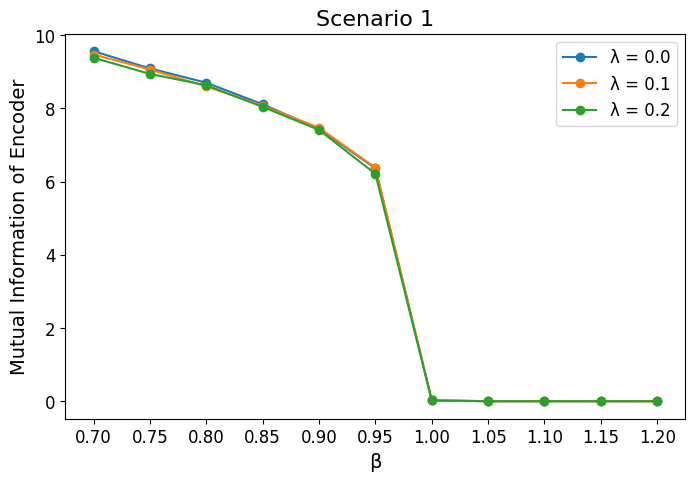

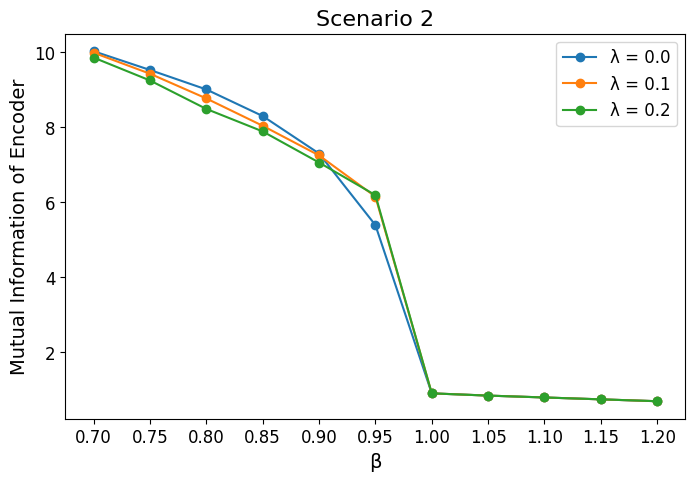

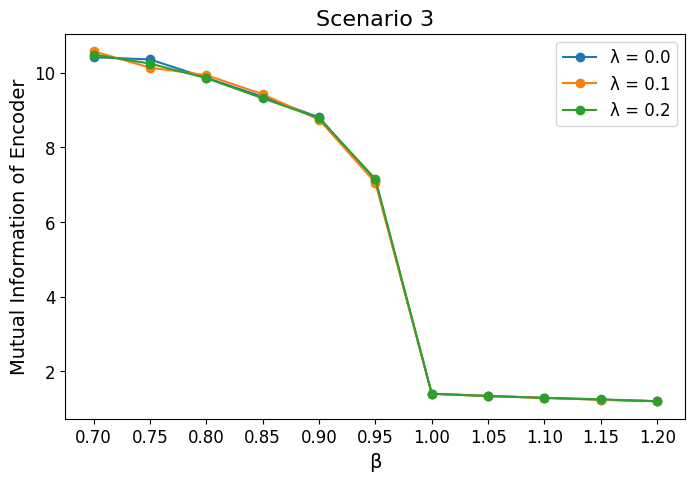

In [17]:
# Extract mean of mutual information of encoder scores for each case
mean_en_mi_1 = np.array([entry[0] for entry in en_mi_case_1_statistics]).reshape(11, 3).T
mean_en_mi_2 = np.array([entry[0] for entry in en_mi_case_2_statistics]).reshape(11, 3).T
mean_en_mi_3 = np.array([entry[0] for entry in en_mi_case_3_statistics]).reshape(11, 3).T

# Store mutual information of encoder in a dictionary for looping
en_mi_scores = {
    "Scenario_1": mean_en_mi_1,
    "Scenario_2": mean_en_mi_2,
    "Scenario_3": mean_en_mi_3
}

# Loop through each scenario and plot
for scenario, mean_en_mi in en_mi_scores.items():
    plt.figure(figsize=(8, 5))

    # Plot each lambda value as a separate line
    for i, lambda_val in enumerate(lambda_values):
        plt.plot(beta_values, mean_en_mi[i], marker='o', linestyle='-', label=f'λ = {lambda_val}')

    plt.xticks(beta_values, fontsize=12)
    plt.yticks(fontsize=12)
    plt.xlabel("β", fontsize=14)
    plt.ylabel("Mutual Information of Encoder", fontsize=14)
    plt.title(f"{scenario.replace('_', ' ')}", fontsize=16)
    plt.legend(fontsize=12)

    # Save the plot
    filename = f"{scenario}_encoder_MI.png"
    save_filepath = os.path.join(SAVE_PATH, filename)
    plt.savefig(save_filepath)

    plt.show()

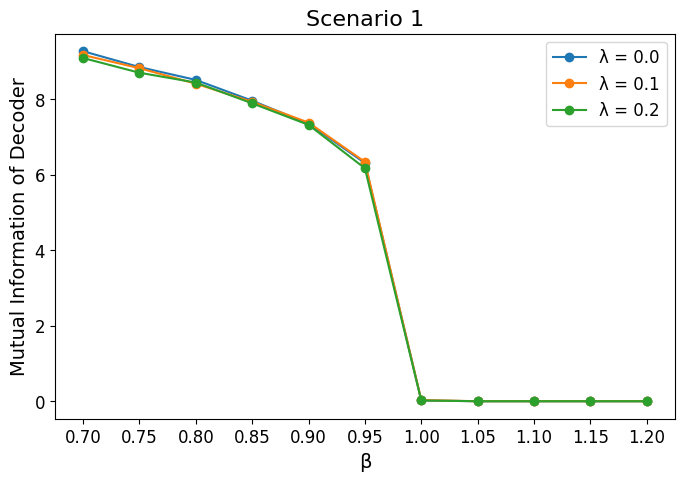

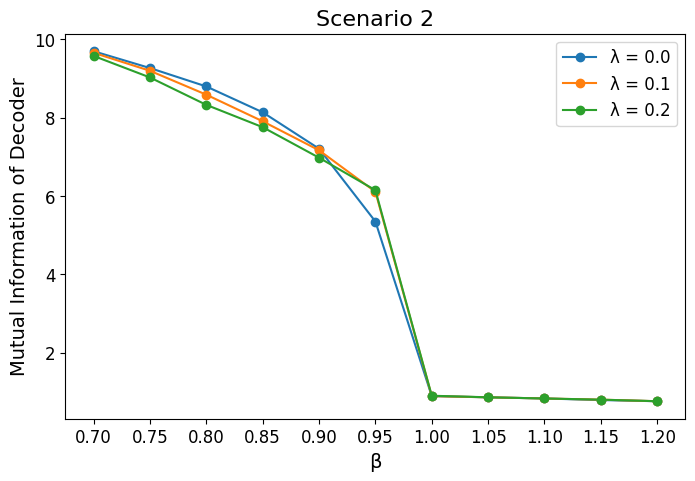

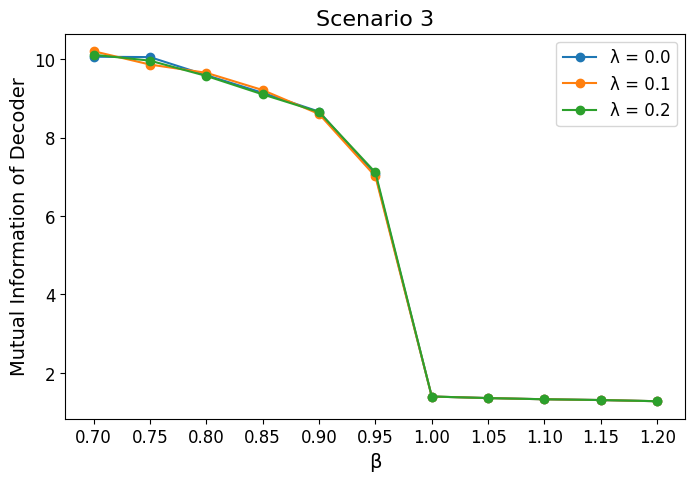

In [18]:
# Extract mean of mutual information of decoder scores for each case
mean_de_mi_1 = np.array([entry[0] for entry in de_mi_case_1_statistics]).reshape(11, 3).T
mean_de_mi_2 = np.array([entry[0] for entry in de_mi_case_2_statistics]).reshape(11, 3).T
mean_de_mi_3 = np.array([entry[0] for entry in de_mi_case_3_statistics]).reshape(11, 3).T

# Store mutual information of decoder in a dictionary for looping
de_mi_scores = {
    "Scenario_1": mean_de_mi_1,
    "Scenario_2": mean_de_mi_2,
    "Scenario_3": mean_de_mi_3
}

# Loop through each scenario and plot
for scenario, mean_de_mi in de_mi_scores.items():
    plt.figure(figsize=(8, 5))

    # Plot each lambda value as a separate line
    for i, lambda_val in enumerate(lambda_values):
        plt.plot(beta_values, mean_de_mi[i], marker='o', linestyle='-', label=f'λ = {lambda_val}')

    plt.xticks(beta_values, fontsize=12)
    plt.yticks(fontsize=12)
    plt.xlabel("β", fontsize=14)
    plt.ylabel("Mutual Information of Decoder", fontsize=14)
    plt.title(f"{scenario.replace('_', ' ')}", fontsize=16)
    plt.legend(fontsize=12)

    # Save the plot
    filename = f"{scenario}_decoder_MI.png"
    save_filepath = os.path.join(SAVE_PATH, filename)
    plt.savefig(save_filepath)

    plt.show()

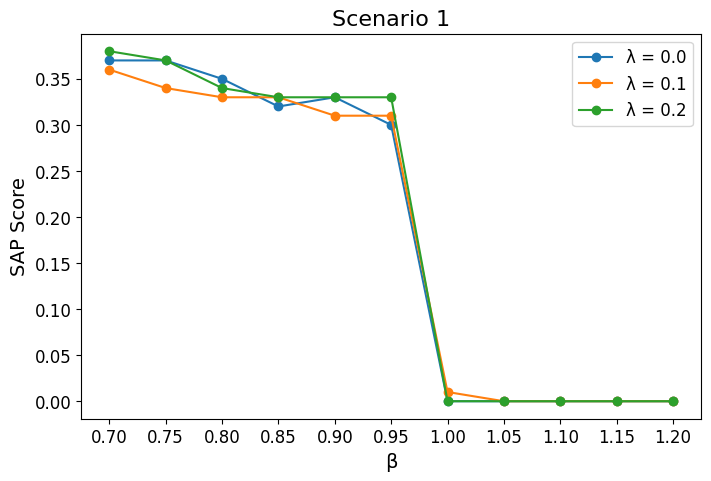

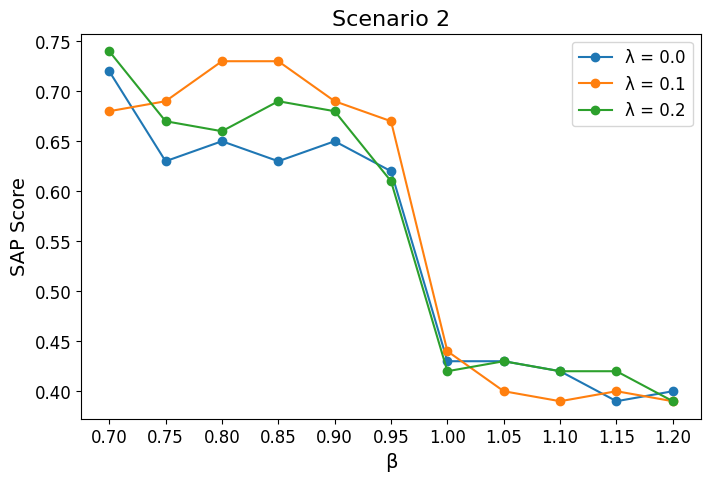

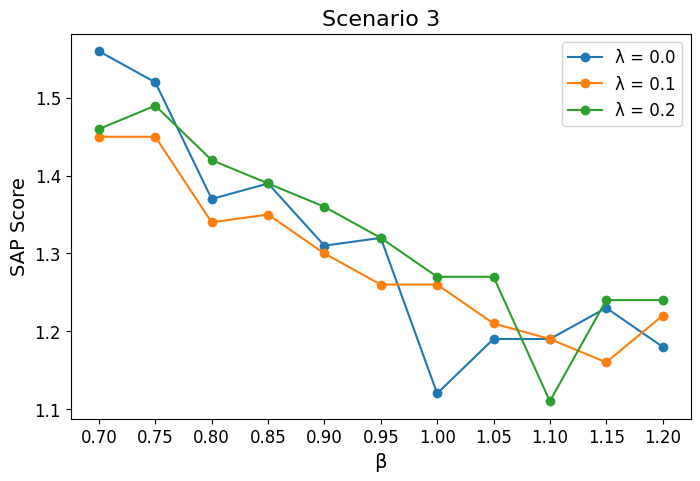

In [19]:
# Extract mean SAP scores for each case
mean_SAP_scores_1 = np.array([entry[0] for entry in SAP_score_case_1_statistics]).reshape(11, 3).T
mean_SAP_scores_2 = np.array([entry[0] for entry in SAP_score_case_2_statistics]).reshape(11, 3).T
mean_SAP_scores_3 = np.array([entry[0] for entry in SAP_score_case_3_statistics]).reshape(11, 3).T

# Store SAP score arrays in a dictionary for looping
SAP_scores = {
    "Scenario_1": mean_SAP_scores_1,
    "Scenario_2": mean_SAP_scores_2,
    "Scenario_3": mean_SAP_scores_3
}

# Loop through each scenario and plot
for scenario, mean_SAP_scores in SAP_scores.items():
    plt.figure(figsize=(8, 5))

    # Plot each lambda value as a separate line
    for i, lambda_val in enumerate(lambda_values):
        plt.plot(beta_values, mean_SAP_scores[i], marker='o', linestyle='-', label=f'λ = {lambda_val}')

    plt.xticks(beta_values, fontsize=12)
    plt.yticks(fontsize=12)
    plt.xlabel("β", fontsize=14)
    plt.ylabel("SAP Score", fontsize=14)
    plt.title(f"{scenario.replace('_', ' ')}", fontsize=16)
    plt.legend(fontsize=12)

    # Save the plot
    filename = f"{scenario}_SAP_Score.png"
    save_filepath = os.path.join(SAVE_PATH, filename)
    plt.savefig(save_filepath)

    plt.show()

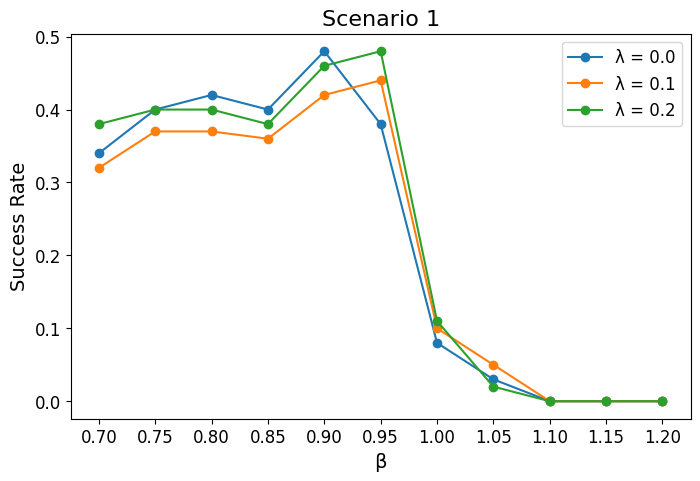

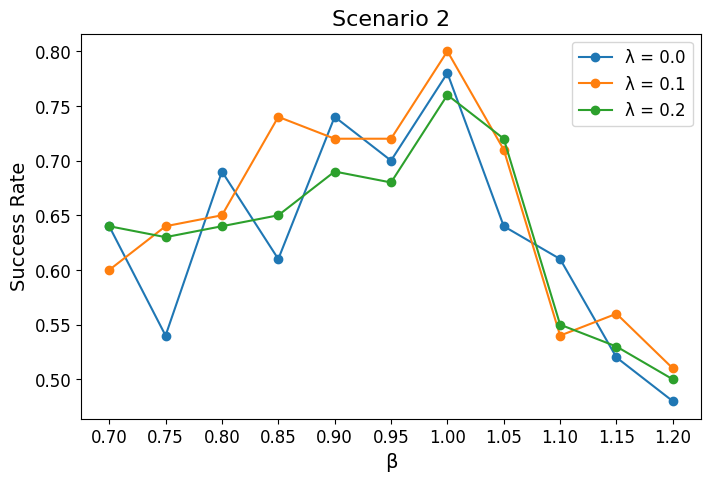

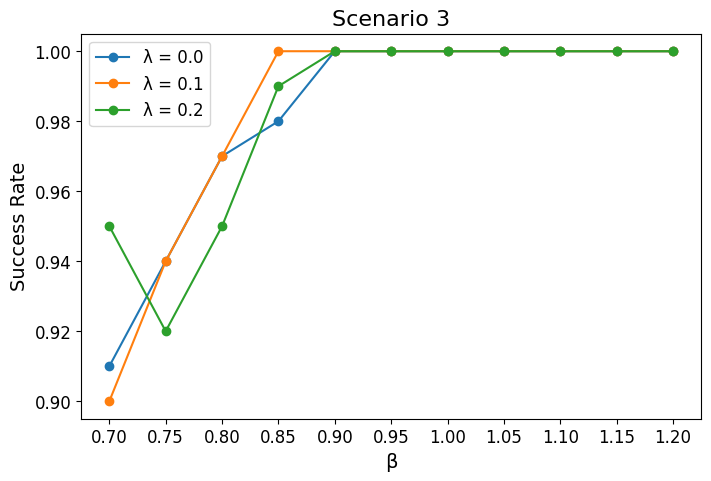

In [20]:
# Extract mean I3 counts for each case
mean_I3_counts_1 = np.array([entry[0] for entry in I3_count_case_1_statistics]).reshape(11, 3).T
mean_I3_counts_2 = np.array([entry[0] for entry in I3_count_case_2_statistics]).reshape(11, 3).T
mean_I3_counts_3 = np.array([entry[0] for entry in I3_count_case_3_statistics]).reshape(11, 3).T

# Store I3 count arrays in a dictionary for looping
I3_counts = {
    "Scenario_1": mean_I3_counts_1,
    "Scenario_2": mean_I3_counts_2,
    "Scenario_3": mean_I3_counts_3
}

# Loop through each scenario and plot
for scenario, mean_I3_counts in I3_counts.items():
    plt.figure(figsize=(8, 5))

    # Plot each lambda value as a separate line
    for i, lambda_val in enumerate(lambda_values):
        plt.plot(beta_values, mean_I3_counts[i], marker='o', linestyle='-', label=f'λ = {lambda_val}')

    plt.xticks(beta_values, fontsize=12)
    plt.yticks(fontsize=12)
    plt.xlabel("β", fontsize=14)
    plt.ylabel("Success Rate", fontsize=14)
    plt.title(f"{scenario.replace('_', ' ')}", fontsize=16)
    plt.legend(fontsize=12)

    # Save the plot
    filename = f"{scenario}_I3_Disentanglement.png"
    save_filepath = os.path.join(SAVE_PATH, filename)
    plt.savefig(save_filepath)

    plt.show()

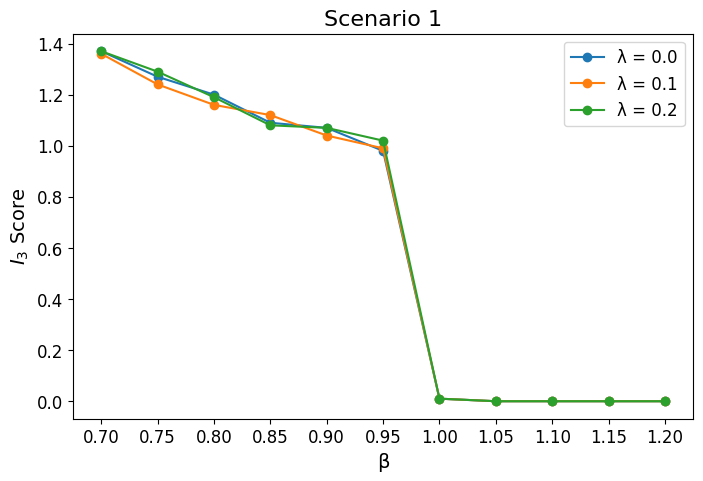

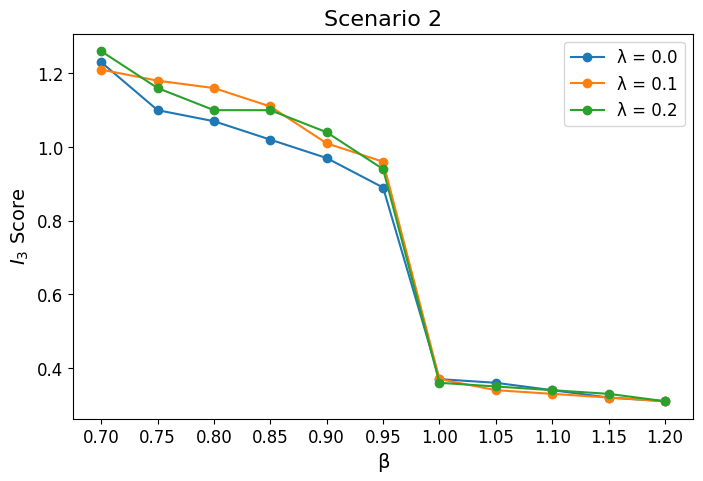

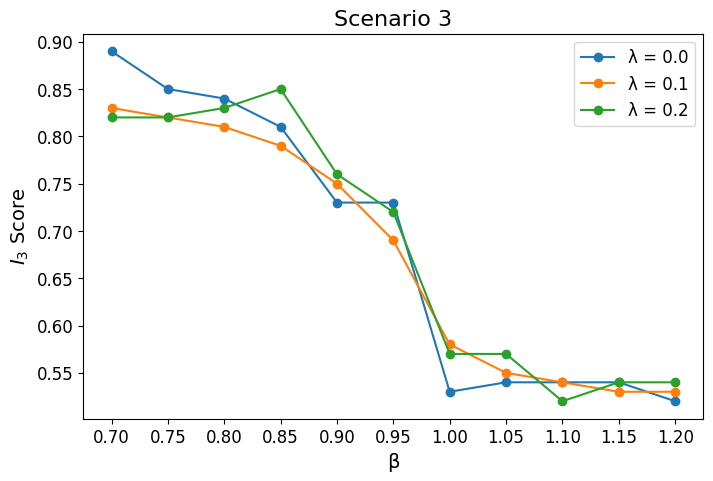

In [21]:
# Extract mean I3 scores for each case
mean_I3_scores_1 = np.array([entry[0] for entry in I3_score_case_1_statistics]).reshape(11, 3).T
mean_I3_scores_2 = np.array([entry[0] for entry in I3_score_case_2_statistics]).reshape(11, 3).T
mean_I3_scores_3 = np.array([entry[0] for entry in I3_score_case_3_statistics]).reshape(11, 3).T

# Store I3 score arrays in a dictionary for looping
I3_scores = {
    "Scenario_1": mean_I3_scores_1,
    "Scenario_2": mean_I3_scores_2,
    "Scenario_3": mean_I3_scores_3
}

# Loop through each scenario and plot
for scenario, mean_I3_scores in I3_scores.items():
    plt.figure(figsize=(8, 5))

    # Plot each lambda value as a separate line
    for i, lambda_val in enumerate(lambda_values):
        plt.plot(beta_values, mean_I3_scores[i], marker='o', linestyle='-', label=f'λ = {lambda_val}')

    plt.xticks(beta_values, fontsize=12)
    plt.yticks(fontsize=12)
    plt.xlabel("β", fontsize=14)
    plt.ylabel("$I_3$ Score", fontsize=14)
    plt.title(f"{scenario.replace('_', ' ')}", fontsize=16)
    plt.legend(fontsize=12)

    # Save the plot
    filename = f"{scenario}_I3_Score.png"
    save_filepath = os.path.join(SAVE_PATH, filename)
    plt.savefig(save_filepath)
    
    plt.show()